<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 4.89e-04 | train loss 0.8881 acc 0.599 | val loss 0.6108 acc 0.764 *


[EfficientNet-B0] Epoch   2/100 | LR: 4.89e-04 | train loss 0.4603 acc 0.783 | val loss 0.5203 acc 0.818 *


[EfficientNet-B0] Epoch   3/100 | LR: 4.89e-04 | train loss 0.3173 acc 0.860 | val loss 0.5261 acc 0.834


[EfficientNet-B0] Epoch   4/100 | LR: 4.89e-04 | train loss 0.2320 acc 0.889 | val loss 0.4314 acc 0.853 *


...

[EfficientNet-B0] Epoch  18/100 | LR: 4.89e-07 | train loss 0.0678 acc 0.976 | val loss 0.4415 acc 0.879


[EfficientNet-B0] Epoch  19/100 | LR: 4.89e-07 | train loss 0.0641 acc 0.977 | val loss 0.4135 acc 0.887


[EfficientNet-B0] Epoch  20/100 | LR: 4.89e-08 | train loss 0.0708 acc 0.968 | val loss 0.4047 acc 0.877


[EfficientNet-B0] Epoch  21/100 | LR: 4.89e-08 | train loss 0.0629 acc 0.977 | val loss 0.4199 acc 0.879


[EfficientNet-B0] Epoch  22/100 | LR: 4.89e-08 | train loss 0.0661 acc 0.981 | val loss 0.4055 acc 0.883

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 22.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3947)


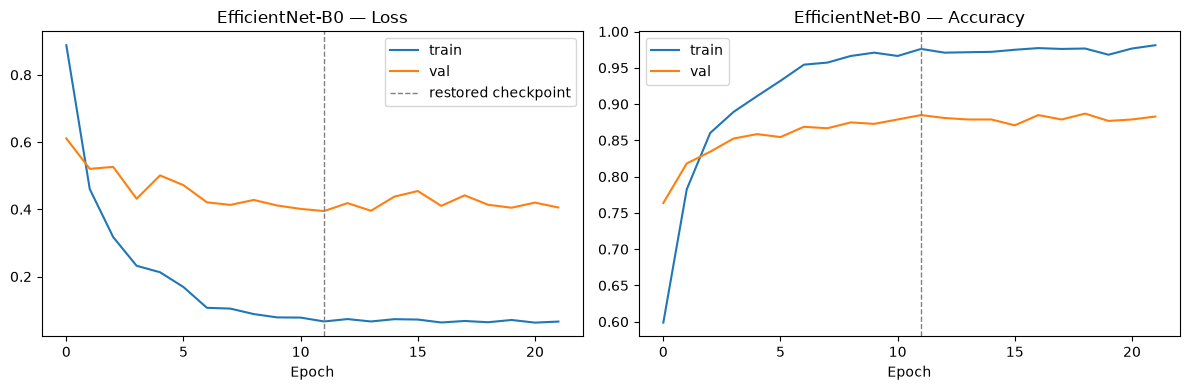

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.843


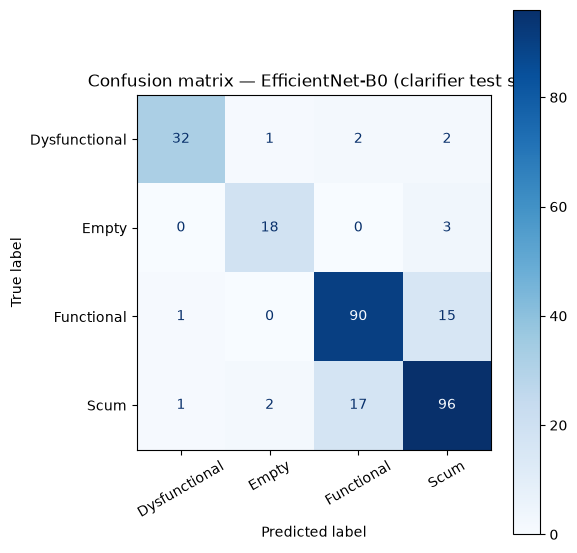

               precision    recall  f1-score   support

Dysfunctional      0.941     0.865     0.901        37
        Empty      0.857     0.857     0.857        21
   Functional      0.826     0.849     0.837       106
         Scum      0.828     0.828     0.828       116

     accuracy                          0.843       280
    macro avg      0.863     0.850     0.856       280
 weighted avg      0.844     0.843     0.843       280



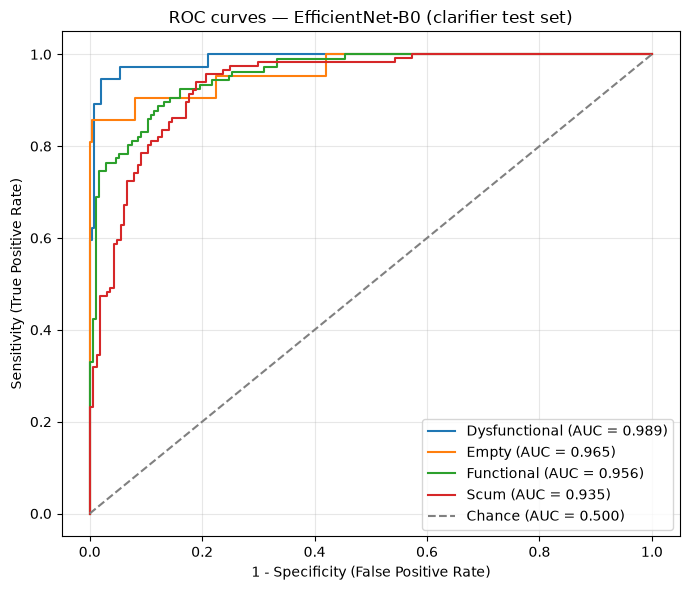

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.989
  Empty          : 0.965
  Functional     : 0.956
  Scum           : 0.935

Mean AUC (over 4/4 classes with test examples): 0.962


(np.float64(0.8428571428571429),
 {'Dysfunctional': 0.9894338783227672,
  'Empty': 0.9652509652509651,
  'Functional': 0.9563543699848188,
  'Scum': 0.9351345668629101})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/clarifier_noaug/results_clarifier_efficientnet_b0_stratified.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
